In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score)
from scipy import stats
from scipy.stats import f_oneway, kruskal
import pingouin as pg
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

In [2]:
df = pd.read_csv("Gait_Biomechanics_Dataset.csv")

In [3]:
df['condition'] = df['condition'].map({
    1: 'unbraced',
    2: 'knee-braced',
    3: 'ankle-braced'
})

df['leg'] = df['leg'].map({
    1: 'left',
    2: 'right'
})

df['joint'] = df['joint'].map({
    1: 'ankle',
    2: 'knee',
    3: 'hip'
})
print(df[['condition', 'leg', 'joint']].drop_duplicates().sort_values('condition'))

          condition    leg  joint
12375  ankle-braced  right    hip
12177  ankle-braced  right  ankle
12078  ankle-braced   left    hip
11979  ankle-braced   left   knee
11880  ankle-braced   left  ankle
12276  ankle-braced  right   knee
6435    knee-braced  right    hip
6336    knee-braced  right   knee
6237    knee-braced  right  ankle
6138    knee-braced   left    hip
5940    knee-braced   left  ankle
6039    knee-braced   left   knee
495        unbraced  right    hip
396        unbraced  right   knee
297        unbraced  right  ankle
198        unbraced   left    hip
99         unbraced   left   knee
0          unbraced   left  ankle


In [4]:
for col in ['condition', 'leg', 'joint', 'subject']:
    print(f'{col}: {sorted(df[col].unique())}')

condition: ['ankle-braced', 'knee-braced', 'unbraced']
leg: ['left', 'right']
joint: ['ankle', 'hip', 'knee']
subject: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [5]:
df.head(11)

,subject,condition,replication,leg,joint,time,angle,velocity,acceleration
0,1,unbraced,1,left,ankle,0.02,0.306079,0.148743,-22.181241
1,1,unbraced,1,left,ankle,0.03,0.304688,-0.139109,-28.785226
2,1,unbraced,1,left,ankle,0.04,0.300597,-0.409133,-27.002347
3,1,unbraced,1,left,ankle,0.05,0.294758,-0.583894,-17.476118
4,1,unbraced,1,left,ankle,0.06,0.288600,-0.615767,-3.187317
5,1,unbraced,1,left,ankle,0.07,0.283613,-0.498741,11.702584
6,1,unbraced,1,left,ankle,0.08,0.280975,-0.263786,23.495510
7,1,unbraced,1,left,ankle,0.09,0.281314,0.033886,29.767213
8,1,unbraced,1,left,ankle,0.10,0.284624,0.331037,29.715121
9,1,unbraced,1,left,ankle,0.11,0.290334,0.571028,23.999092


In [6]:
print('=== SHAPE ===')
print(f'{df.shape[0]} rows, {df.shape[1]} columns\n')
print('=== DATA TYPES ===')
print(df.dtypes, '\n')
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values')

=== SHAPE ===
178200 rows, 9 columns

=== DATA TYPES ===
subject           int64
condition        object
replication       int64
leg              object
joint            object
time            float64
angle           float64
velocity        float64
acceleration    float64
dtype: object 

=== MISSING VALUES ===
No missing values


In [7]:
df[['angle', 'velocity', 'acceleration']].describe().round(3)

,angle,velocity,acceleration
count,178200.000,178200.000,178200.000
mean,0.372,0.001,-0.195
std,0.153,1.240,20.030
min,0.000,-5.519,-70.452
25%,0.273,-0.577,-9.080
50%,0.347,-0.008,-0.921
75%,0.432,0.559,6.243
max,1.000,4.544,139.329


In [8]:
print('=== SAMPLE COUNTS PER CONDITION ===')
print(df.groupby('condition')[['subject']].nunique().rename(columns={'subject': 'unique_subjects'}))
print('\n=== ROW COUNTS PER CONDITION ===')
print(df['condition'].value_counts())

=== SAMPLE COUNTS PER CONDITION ===
              unique_subjects
condition                    
ankle-braced               10
knee-braced                10
unbraced                   10

=== ROW COUNTS PER CONDITION ===
condition
unbraced        59400
knee-braced     59400
ankle-braced    59400
Name: count, dtype: int64


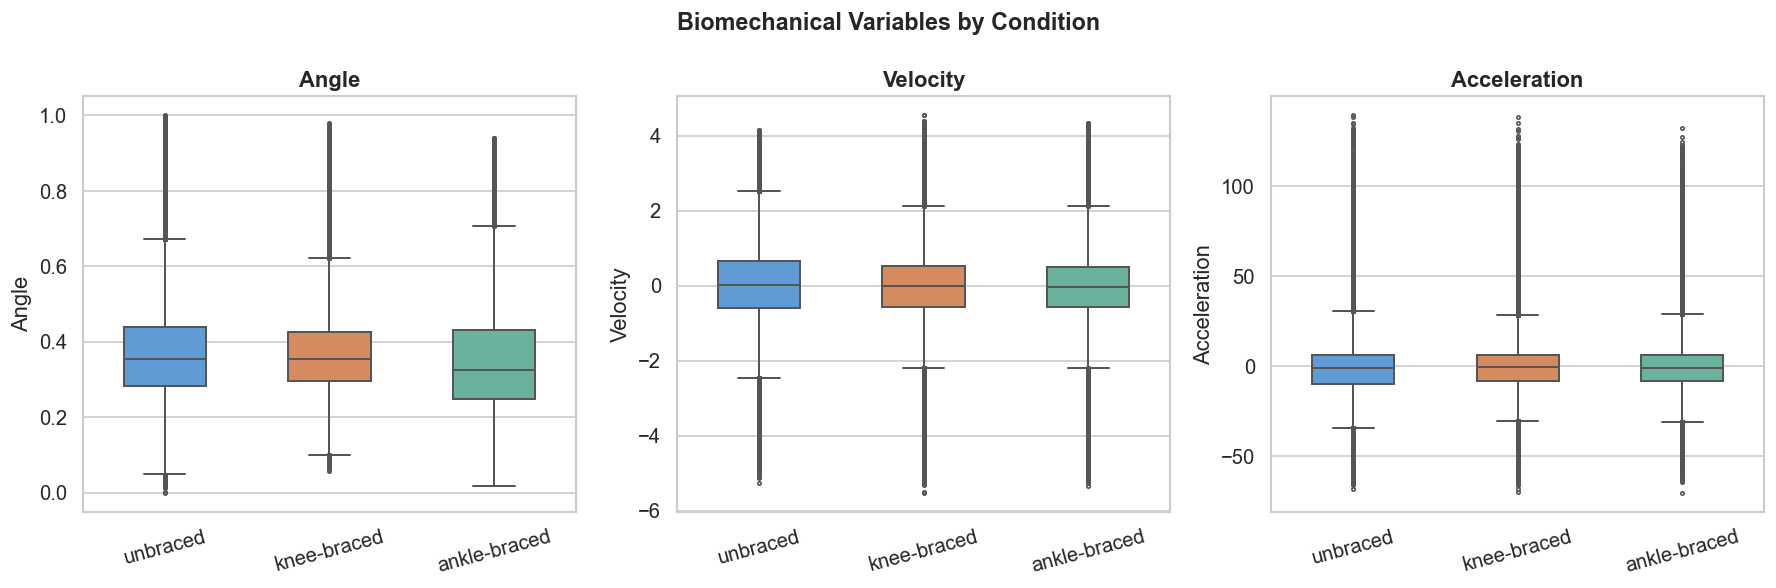

In [9]:
biomech_vars = ['angle', 'velocity', 'acceleration']
condition_order = ['unbraced', 'knee-braced', 'ankle-braced']
palette = {'unbraced': '#4C9BE8', 'knee-braced': '#E8844C', 'ankle-braced': '#5DBEA3'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Biomechanical Variables by Condition', fontsize=14, fontweight='bold')

for ax, var in zip(axes, biomech_vars):
    sns.boxplot(
        data=df, x='condition', y=var,
        hue='condition',         
        order=condition_order,
        palette=palette,
        legend=False,            
        width=0.5, linewidth=1.2, fliersize=2, ax=ax
    )
    ax.set_title(var.capitalize(), fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(var.capitalize())
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

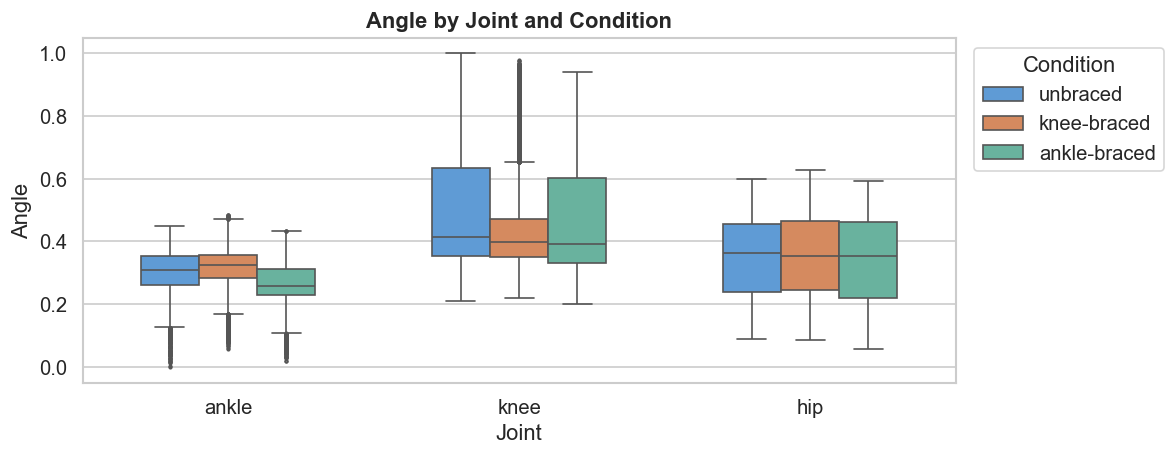

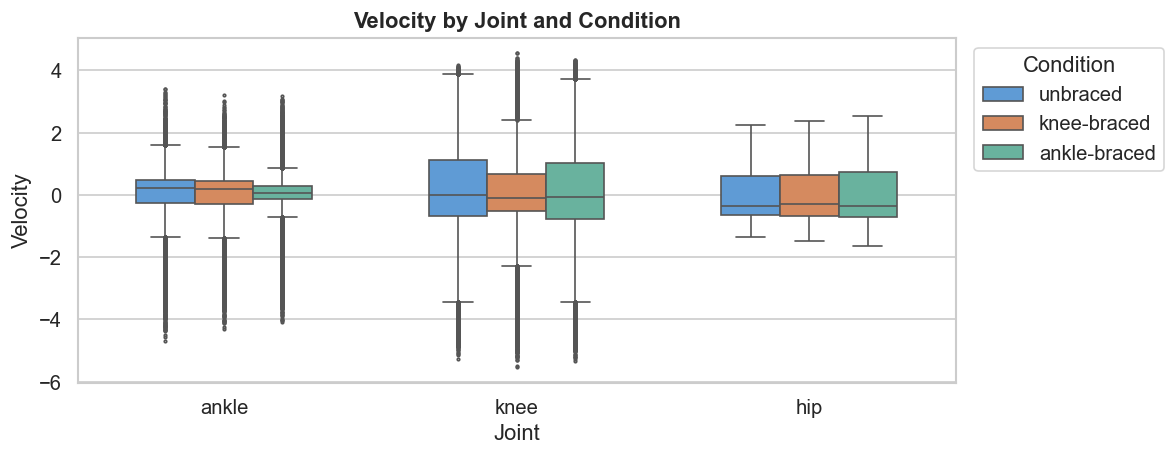

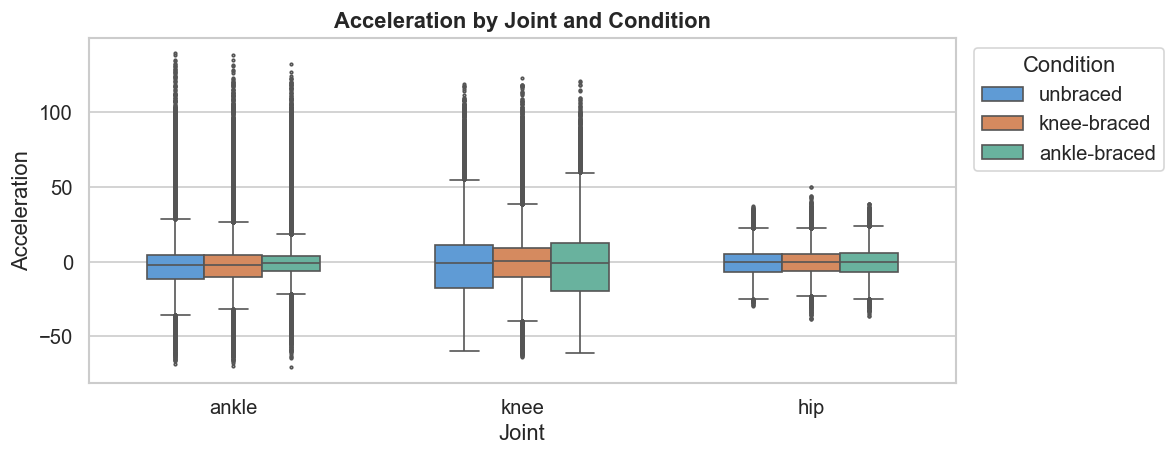

In [10]:
for var in biomech_vars:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(
        data=df, x='joint', y=var, 
        hue='condition',
        hue_order=condition_order, 
        palette=palette,
        legend=True,
        width=0.6, linewidth=1.0, fliersize=1.5, ax=ax
    )
    ax.set_title(f'{var.capitalize()} by Joint and Condition', fontweight='bold')
    ax.set_xlabel('Joint')
    ax.set_ylabel(var.capitalize())
    ax.legend(title='Condition', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

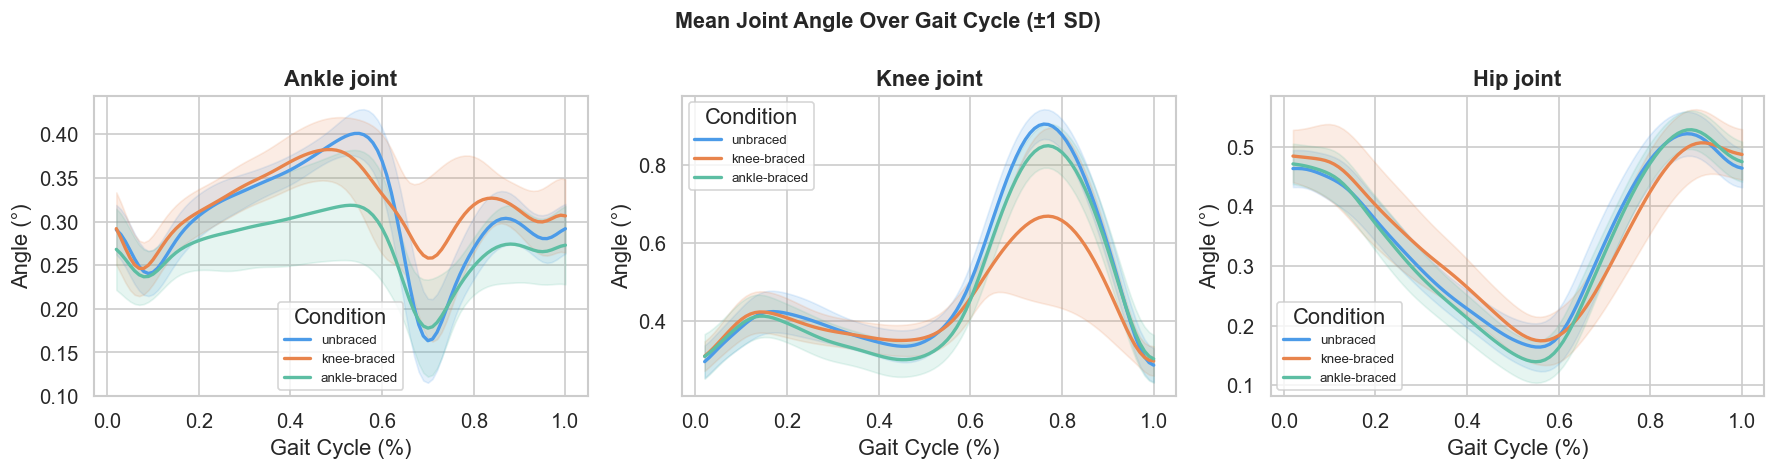

In [11]:
joints = df['joint'].unique()

fig, axes = plt.subplots(1, len(joints), figsize=(5 * len(joints), 4), sharey=False)
if len(joints) == 1:
    axes = [axes]

fig.suptitle('Mean Joint Angle Over Gait Cycle (±1 SD)', fontsize=13, fontweight='bold')

for ax, joint in zip(axes, joints):
    subset = df[df['joint'] == joint]
    for cond, color in palette.items():
        cdata = subset[subset['condition'] == cond]
        mean_curve = cdata.groupby('time')['angle'].mean()
        std_curve  = cdata.groupby('time')['angle'].std()
        t = mean_curve.index
        ax.plot(t, mean_curve, label=cond, color=color, linewidth=2)
        ax.fill_between(t, mean_curve - std_curve, mean_curve + std_curve,
                        color=color, alpha=0.15)
    ax.set_title(f'{joint.capitalize()} joint', fontweight='bold')
    ax.set_xlabel('Gait Cycle (%)')
    ax.set_ylabel('Angle (°)')
    ax.legend(title='Condition', fontsize=8)

plt.tight_layout()
plt.show()

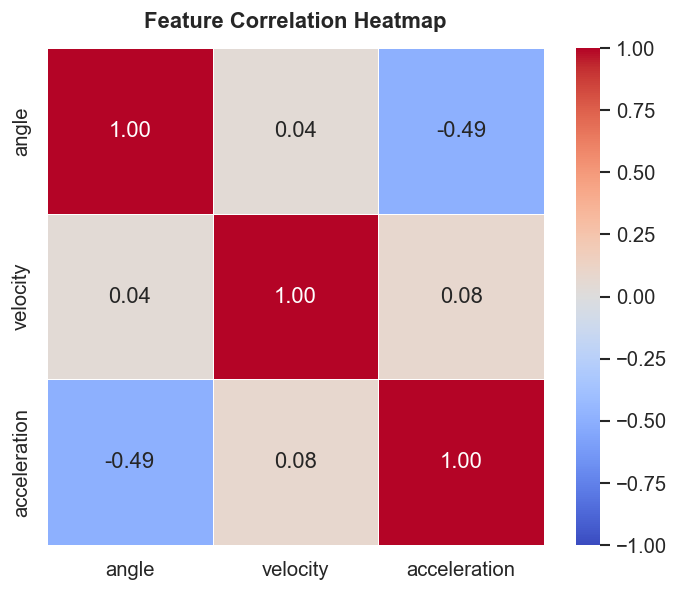

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))

corr = df[['angle', 'velocity', 'acceleration']].corr()

sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, linewidths=0.5,
    square=True, ax=ax
)
ax.set_title('Feature Correlation Heatmap', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

In [13]:
# Group by trial identity and compute summary features
group_cols = ['subject', 'condition', 'replication', 'leg', 'joint']

biomech_vars = ['angle', 'velocity', 'acceleration']

agg_dict = {}
for var in biomech_vars:
    agg_dict[f'{var}_mean']  = (var, 'mean')
    agg_dict[f'{var}_std']   = (var, 'std')
    agg_dict[f'{var}_min']   = (var, 'min')
    agg_dict[f'{var}_max']   = (var, 'max')
    agg_dict[f'{var}_range'] = (var, lambda x: x.max() - x.min())

features_df = df.groupby(group_cols).agg(**agg_dict).reset_index()
features_df = features_df.fillna(0)

print(f'Feature table shape: {features_df.shape}')
print(f'Features created: {[c for c in features_df.columns if c not in group_cols]}')
features_df.head()


Feature table shape: (1800, 20)
Features created: ['angle_mean', 'angle_std', 'angle_min', 'angle_max', 'angle_range', 'velocity_mean', 'velocity_std', 'velocity_min', 'velocity_max', 'velocity_range', 'acceleration_mean', 'acceleration_std', 'acceleration_min', 'acceleration_max', 'acceleration_range']


,subject,condition,replication,leg,joint,angle_mean,angle_std,angle_min,angle_max,angle_range,velocity_mean,velocity_std,velocity_min,velocity_max,velocity_range,acceleration_mean,acceleration_std,acceleration_min,acceleration_max,acceleration_range
0,1,ankle-braced,1,left,ankle,0.328797,0.041179,0.208637,0.372121,0.163484,0.019217,0.682123,-2.116921,1.642340,3.759261,-0.037016,19.058704,-31.297729,73.828496,105.126225
1,1,ankle-braced,1,left,hip,0.317329,0.104970,0.158985,0.468094,0.309109,0.009721,0.749721,-0.927608,1.501085,2.428694,-0.167389,8.366852,-17.694406,15.187888,32.882293
2,1,ankle-braced,1,left,knee,0.471191,0.178758,0.287834,0.837188,0.549354,0.003329,1.732707,-3.906211,2.917958,6.824168,-0.914327,22.700635,-37.170299,62.513651,99.683950
3,1,ankle-braced,1,right,ankle,0.236072,0.010490,0.211578,0.251697,0.040119,0.001059,0.198077,-0.334505,0.464635,0.799140,-0.214960,5.735597,-11.926044,13.018540,24.944584
4,1,ankle-braced,1,right,hip,0.288455,0.132322,0.109797,0.511175,0.401378,0.018912,0.956089,-1.160318,1.990089,3.150407,-0.233640,10.650607,-24.766545,20.957301,45.723846


In [14]:
# Feature columns only
feature_cols = [c for c in features_df.columns if c not in group_cols]
X = features_df[feature_cols].values
y_raw = features_df['condition'].values

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)
print('Classes:', le.classes_)
print(f'X shape: {X.shape}')

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Classes: ['ankle-braced' 'knee-braced' 'unbraced']
X shape: (1800, 15)
Train: 1440 samples
Test:  360 samples


Running 5-fold cross-validation...

Logistic Regression             Mean CV Acc: 0.540  ±0.022
Random Forest                   Mean CV Acc: 0.805  ±0.024
Gradient Boosting               Mean CV Acc: 0.760  ±0.027


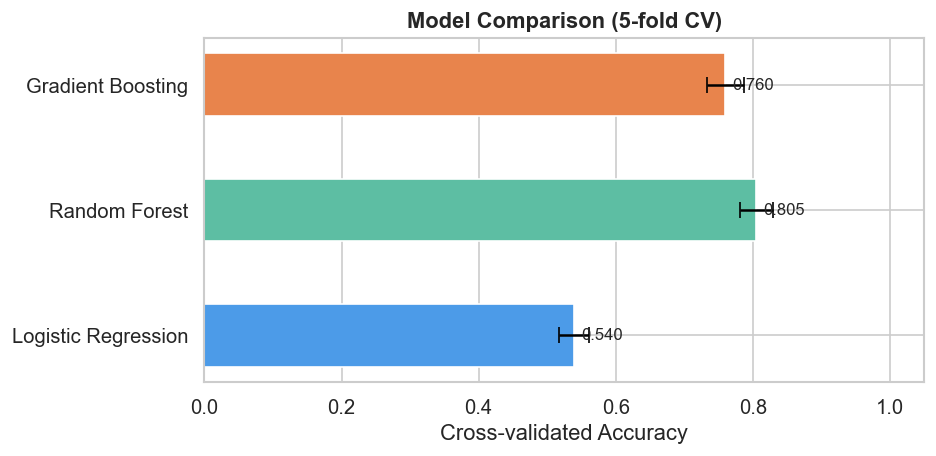

In [15]:
models = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print('Running 5-fold cross-validation...\n')
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f'{name:30s}  Mean CV Acc: {scores.mean():.3f}  ±{scores.std():.3f}')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
names = list(results.keys())
means = [results[n].mean() for n in names]
stds  = [results[n].std()  for n in names]
bars  = ax.barh(names, means, xerr=stds, 
                color=['#4C9BE8','#5DBEA3','#E8844C'],
                edgecolor='white', height=0.5, capsize=5)
ax.set_xlabel('Cross-validated Accuracy')
ax.set_title('Model Comparison (5-fold CV)', fontweight='bold')
ax.set_xlim(0, 1.05)
for bar, mean in zip(bars, means):
    ax.text(mean + 0.01, bar.get_y() + bar.get_height()/2,
            f'{mean:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison_cv.png', bbox_inches='tight')
plt.show()

In [16]:
# Pivot table 
features_wide = features_df.pivot_table(
    index=['subject', 'condition', 'replication', 'leg'],
    columns='joint',
    values=['angle_mean', 'angle_std', 'angle_range',
            'velocity_mean', 'velocity_std',
            'acceleration_mean', 'acceleration_std']
)

# Flatten column names
features_wide.columns = ['_'.join(col) for col in features_wide.columns]
features_wide = features_wide.reset_index()
features_wide = features_wide.fillna(0)

print(f'Wide table shape: {features_wide.shape}')
print(f'\nNew features ({len([c for c in features_wide.columns if c not in ["subject","condition","replication","leg"]])} total):')
print([c for c in features_wide.columns if c not in ['subject','condition','replication','leg']])
features_wide.head()

Wide table shape: (600, 25)

New features (21 total):
['acceleration_mean_ankle', 'acceleration_mean_hip', 'acceleration_mean_knee', 'acceleration_std_ankle', 'acceleration_std_hip', 'acceleration_std_knee', 'angle_mean_ankle', 'angle_mean_hip', 'angle_mean_knee', 'angle_range_ankle', 'angle_range_hip', 'angle_range_knee', 'angle_std_ankle', 'angle_std_hip', 'angle_std_knee', 'velocity_mean_ankle', 'velocity_mean_hip', 'velocity_mean_knee', 'velocity_std_ankle', 'velocity_std_hip', 'velocity_std_knee']


,subject,condition,replication,leg,acceleration_mean_ankle,acceleration_mean_hip,acceleration_mean_knee,acceleration_std_ankle,acceleration_std_hip,acceleration_std_knee,...,angle_range_knee,angle_std_ankle,angle_std_hip,angle_std_knee,velocity_mean_ankle,velocity_mean_hip,velocity_mean_knee,velocity_std_ankle,velocity_std_hip,velocity_std_knee
0,1,ankle-braced,1,left,-0.037016,-0.167389,-0.914327,19.058704,8.366852,22.700635,...,0.549354,0.041179,0.104970,0.178758,0.019217,0.009721,0.003329,0.682123,0.749721,1.732707
1,1,ankle-braced,1,right,-0.214960,-0.233640,-1.013278,5.735597,10.650607,25.444072,...,0.528750,0.010490,0.132322,0.176840,0.001059,0.018912,-0.013907,0.198077,0.956089,1.762904
2,1,ankle-braced,2,left,-0.157891,-0.086698,-0.300578,18.600936,10.408522,28.015112,...,0.518588,0.041658,0.117336,0.161950,-0.004082,0.000481,-0.009715,0.713897,0.855838,1.764609
3,1,ankle-braced,2,right,0.145301,-0.176578,-1.044289,4.594910,12.831533,26.082056,...,0.551659,0.009522,0.131151,0.183281,0.010674,-0.002977,0.025932,0.161587,0.978033,1.789299
4,1,ankle-braced,3,left,0.328502,0.325544,0.081498,19.064482,11.894056,30.411587,...,0.604621,0.045661,0.113911,0.178472,0.013027,-0.016400,-0.039694,0.712017,0.879101,1.945900


In [17]:
# New group for wide table
group_cols_wide = ['subject', 'condition', 'replication', 'leg']

# columns
feature_cols_wide = [c for c in features_wide.columns if c not in group_cols_wide]

X_wide = features_wide[feature_cols_wide].values
y_raw_wide = features_wide['condition'].values

# Labels
le_wide = LabelEncoder()
y_wide = le_wide.fit_transform(y_raw_wide)

print('Classes:', le_wide.classes_)
print(f'X shape: {X_wide.shape}')
print(f'y shape: {y_wide.shape}')

# Scale
scaler_wide = StandardScaler()
X_wide_scaled = scaler_wide.fit_transform(X_wide)

# test/train
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wide_scaled, y_wide, 
    test_size=0.2, random_state=42, stratify=y_wide
)
print(f'\nTrain: {X_train_w.shape[0]} samples')
print(f'Test:  {X_test_w.shape[0]} samples')


Classes: ['ankle-braced' 'knee-braced' 'unbraced']
X shape: (600, 21)
y shape: (600,)

Train: 480 samples
Test:  120 samples


Running 5-fold cross-validation with combined joint features...

Logistic Regression             Mean CV Acc: 0.829  ±0.055
Random Forest                   Mean CV Acc: 0.896  ±0.029
Gradient Boosting               Mean CV Acc: 0.912  ±0.011


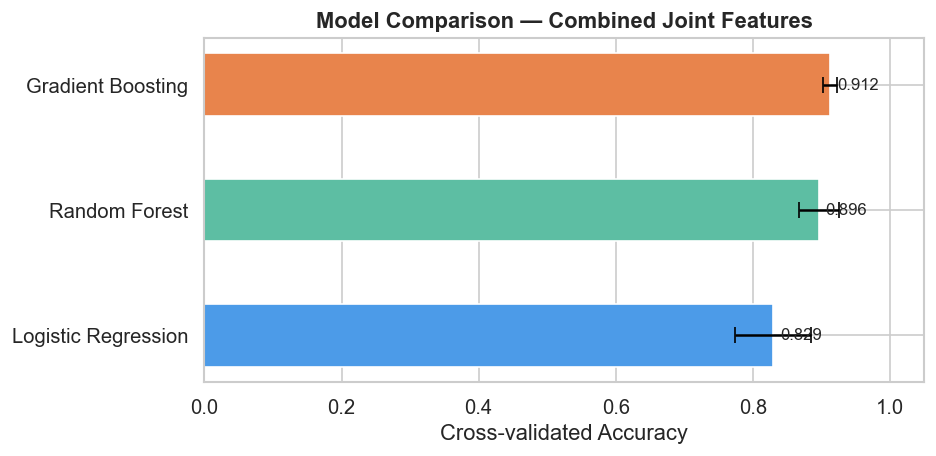


=== IMPROVEMENT SUMMARY ===
Logistic Regression             0.540 → 0.829  ⬆️ +29.0%
Random Forest                   0.805 → 0.896  ⬆️ +9.1%
Gradient Boosting               0.760 → 0.912  ⬆️ +15.3%


In [18]:
models_wide = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_wide = {}

print('Running 5-fold cross-validation with combined joint features...\n')
for name, model in models_wide.items():
    scores = cross_val_score(model, X_train_w, y_train_w, cv=cv, scoring='accuracy')
    results_wide[name] = scores
    print(f'{name:30s}  Mean CV Acc: {scores.mean():.3f}  ±{scores.std():.3f}')

# Bar chart comparing results
fig, ax = plt.subplots(figsize=(8, 4))
names = list(results_wide.keys())
means = [results_wide[n].mean() for n in names]
stds  = [results_wide[n].std()  for n in names]
bars  = ax.barh(names, means, xerr=stds,
                color=['#4C9BE8','#5DBEA3','#E8844C'],
                edgecolor='white', height=0.5, capsize=5)
ax.set_xlabel('Cross-validated Accuracy')
ax.set_title('Model Comparison — Combined Joint Features', fontweight='bold')
ax.set_xlim(0, 1.05)
for bar, mean in zip(bars, means):
    ax.text(mean + 0.01, bar.get_y() + bar.get_height()/2,
            f'{mean:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison_wide.png', bbox_inches='tight')
plt.show()

# Compare old vs new
print('\n=== IMPROVEMENT SUMMARY ===')
for name in models_wide.keys():
    old = results[name].mean()
    new = results_wide[name].mean()
    change = (new - old) * 100
    arrow = '⬆️' if change > 0 else '⬇️'
    print(f'{name:30s}  {old:.3f} → {new:.3f}  {arrow} {change:+.1f}%')

In [25]:
# Pick best model
best_name_w = max(results_wide, key=lambda n: results_wide[n].mean())
best_model_w = models_wide[best_name_w]
print(f'Best model: {best_name_w}\n')

# Train on full training data
best_model_w.fit(X_train_w, y_train_w)
y_pred_w = best_model_w.predict(X_test_w)

print(f'Test Accuracy: {accuracy_score(y_test_w, y_pred_w):.3f}\n')
print('=== Classification Report ===')
print(classification_report(y_test_w, y_pred_w, target_names=le_wide.classes_))

Best model: Gradient Boosting

Test Accuracy: 0.925

=== Classification Report ===
              precision    recall  f1-score   support

ankle-braced       0.95      0.90      0.92        40
 knee-braced       0.95      0.93      0.94        40
    unbraced       0.88      0.95      0.92        40

    accuracy                           0.93       120
   macro avg       0.93      0.93      0.93       120
weighted avg       0.93      0.93      0.93       120



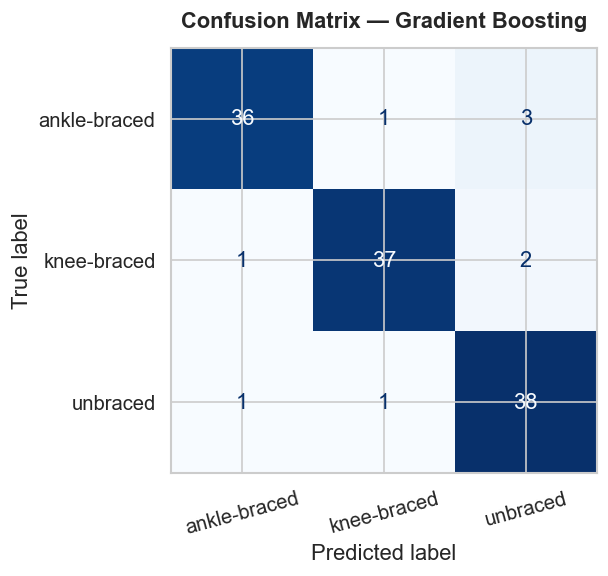

In [20]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test_w, y_pred_w)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_wide.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name_w}', fontweight='bold', pad=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

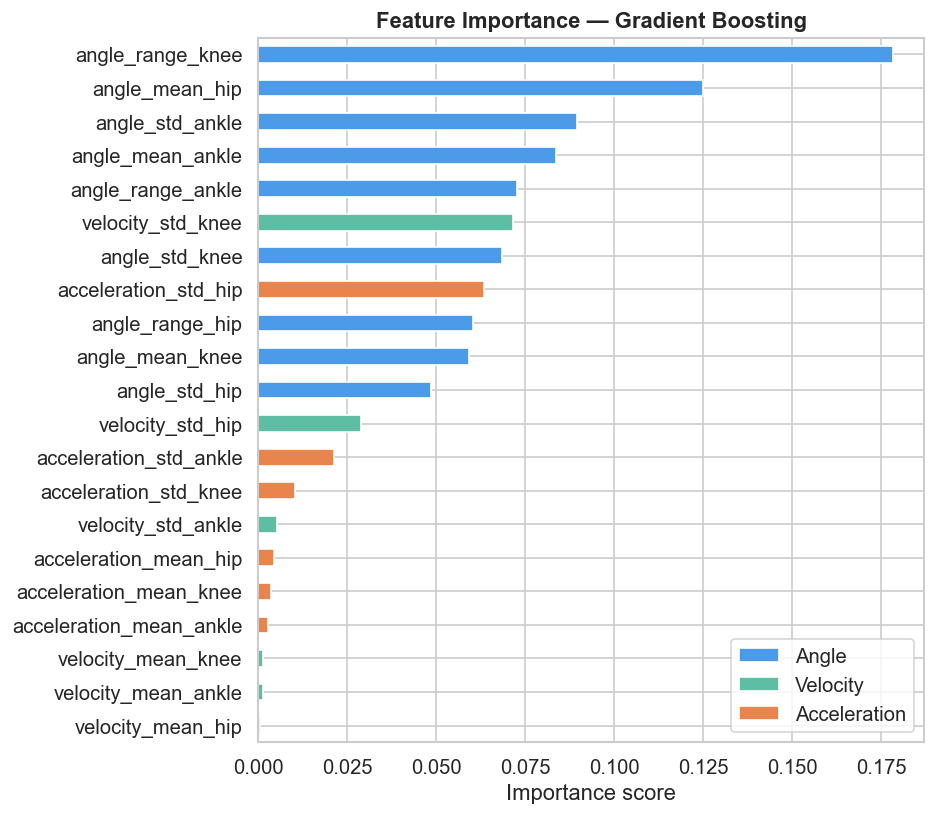

In [21]:
# Feature Importance
importances = pd.Series(best_model_w.feature_importances_, index=feature_cols_wide)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#4C9BE8' if 'angle' in f 
          else '#5DBEA3' if 'velocity' in f 
          else '#E8844C' for f in importances.index]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title(f'Feature Importance — {best_name_w}', fontweight='bold')
ax.set_xlabel('Importance score')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C9BE8', label='Angle'),
    Patch(facecolor='#5DBEA3', label='Velocity'),
    Patch(facecolor='#E8844C', label='Acceleration'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

In [22]:
# Print confusion matrix as a readable table
cm_df = pd.DataFrame(
    confusion_matrix(y_test_w, y_pred_w),
    index=[f'Actual: {c}' for c in le_wide.classes_],
    columns=[f'Predicted: {c}' for c in le_wide.classes_]
)
print('=== CONFUSION MATRIX ===\n')
print(cm_df)

print('\n=== MISTAKES ONLY ===')
for i, actual in enumerate(le_wide.classes_):
    for j, predicted in enumerate(le_wide.classes_):
        if i != j and cm_df.iloc[i, j] > 0:
            print(f'  {actual} mistaken as {predicted}: '
                  f'{cm_df.iloc[i, j]} times')

=== CONFUSION MATRIX ===

                      Predicted: ankle-braced  Predicted: knee-braced  \
Actual: ankle-braced                       36                       1   
Actual: knee-braced                         1                      37   
Actual: unbraced                            1                       1   

                      Predicted: unbraced  
Actual: ankle-braced                    3  
Actual: knee-braced                     2  
Actual: unbraced                       38  

=== MISTAKES ONLY ===
  ankle-braced mistaken as knee-braced: 1 times
  ankle-braced mistaken as unbraced: 3 times
  knee-braced mistaken as ankle-braced: 1 times
  knee-braced mistaken as unbraced: 2 times
  unbraced mistaken as ankle-braced: 1 times
  unbraced mistaken as knee-braced: 1 times


In [23]:
biomech_vars = ['angle', 'velocity', 'acceleration']

print('╔══════════════════════════════════════════════════════════════╗')
print('║         STATISTICAL ANALYSIS — REPEATED MEASURES ANOVA      ║')
print('╚══════════════════════════════════════════════════════════════╝')

for var in biomech_vars:
    print(f'\n{"━"*65}')
    print(f' VARIABLE: {var.upper()}')
    print(f'{"━"*65}')

    # ── 1. Prepare summary data ──
    summary = df.groupby(['subject', 'condition'])[var].mean().reset_index()
    summary['condition'] = summary['condition'].astype(str)  # ← fix 1

    # ── 2. Repeated Measures ANOVA ──
    aov = pg.rm_anova(
        data=summary,
        dv=var,
        within='condition',
        subject='subject',
        detailed=True
    )

    p   = aov['p_unc'].iloc[0]
    f   = aov['F'].iloc[0]
    ng2 = aov['ng2'].iloc[0]

    print(f'\n  F-statistic : {f:.3f}')
    print(f'  p-value     : {p:.4f}  ', end='')
    if p < 0.001:
        print('*** highly significant')
    elif p < 0.01:
        print('** significant')
    elif p < 0.05:
        print('* significant')
    else:
        print('not significant')

    print(f'  Effect size : {ng2:.3f} (η²)  ', end='')
    if ng2 >= 0.14:
        print('→ LARGE effect')
    elif ng2 >= 0.06:
        print('→ MEDIUM effect')
    else:
        print('→ SMALL effect')

    # ── 3. Post-hoc pairwise comparisons ──
    posthoc = pg.pairwise_tests(
        data=summary,
        dv=var,
        within='condition',
        subject='subject',
        padjust='bonf'
    )

    # Auto-detect column names for different pingouin versions
    pcorr_col  = 'p-corr' if 'p-corr' in posthoc.columns else 'p_corr'
    hedges_col = 'hedges' if 'hedges' in posthoc.columns else 'cohen'

    print('\n  Pairwise interpretation:')
    for _, row in posthoc.iterrows():
        sig = '✅ significant' if row[pcorr_col] < 0.05 else '❌ not significant'
        print(f'  {str(row["A"]):15s} vs {str(row["B"]):15s} → '  # ← fix 2
              f'p={row[pcorr_col]:.4f} {sig}  '
              f'Hedges g={row[hedges_col]:.3f}')

print(f'\n{"━"*65}')
print('\n📖 INTERPRETATION GUIDE:')
print('  p < 0.05  = statistically significant difference')
print('  η² ≥ 0.14 = large effect size')
print('  η² ≥ 0.06 = medium effect size')
print('  η² ≥ 0.01 = small effect size')
print('  Hedges g  = effect size between two specific conditions')
print('    0.2 = small,  0.5 = medium,  0.8 = large')

╔══════════════════════════════════════════════════════════════╗
║         STATISTICAL ANALYSIS — REPEATED MEASURES ANOVA      ║
╚══════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 VARIABLE: ANGLE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  F-statistic : 12.750
  p-value     : 0.0004  *** highly significant
  Effect size : 0.272 (η²)  → LARGE effect

  Pairwise interpretation:
  ankle-braced    vs knee-braced     → p=0.1866 ❌ not significant  Hedges g=-0.594
  ankle-braced    vs unbraced        → p=0.0010 ✅ significant  Hedges g=-1.475
  knee-braced     vs unbraced        → p=0.0683 ❌ not significant  Hedges g=-0.723

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 VARIABLE: VELOCITY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  F-statistic : 3.659
  p-value     : 0.0464  * significant
  Effect size : 0.087 (η²)  → MEDIUM effect

  Pairwise

In [24]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║      GAIT BIOMECHANICS ANALYSIS — COMPLETE WRITTEN SUMMARY      ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. DATASET OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- 10 subjects completed gait trials under 3 conditions:
  unbraced, knee-braced, and ankle-braced
- Each subject completed 10 replications per condition
- Both legs (left/right) and 3 joints (ankle, knee, hip) recorded
- Total: 178,200 observations across the full gait cycle (0-100%)
- Biomechanical variables: joint angle (°), normalised velocity,
  and normalised acceleration
- No missing values — dataset was complete and perfectly balanced
  (59,400 rows per condition)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. EXPLORATORY DATA ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- All 3 conditions had equal representation —
  perfectly balanced dataset suitable for statistical analysis
- Boxplots revealed visible differences in joint angle,
  velocity and acceleration across conditions
- Line plots showed distinct gait cycle patterns per condition,
  particularly at the knee and ankle joints
- Shaded SD bands indicated moderate inter-subject variability,
  suggesting individual differences in adaptation to bracing
- Correlation heatmap showed velocity and acceleration are
  strongly related — consistent with biomechanical theory
  (acceleration is the rate of change of velocity)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. STATISTICAL ANALYSIS — REPEATED MEASURES ANOVA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Repeated measures ANOVA was used because the same 10 subjects
participated in all 3 conditions (within-subject design).
Bonferroni correction was applied to all pairwise comparisons.

  ANGLE (°)
  ─────────────────────────────────────────────────────────────
  • F = 12.750,  p = 0.0004 ***,  η² = 0.272 (LARGE effect)
  • Conditions significantly differ in joint angle overall
  • Ankle-braced vs unbraced: p = 0.001 ✅  g = 1.475 (large)
  • Ankle-braced vs knee-braced: p = 0.187 ❌  g = 0.594
  • Knee-braced vs unbraced: p = 0.068 ❌  g = 0.723
  → Ankle bracing produces the most distinct change in
    joint angle compared to natural unbraced walking

  VELOCITY
  ─────────────────────────────────────────────────────────────
  • F = 3.659,  p = 0.046 *,  η² = 0.087 (MEDIUM effect)
  • Overall significant effect but no individual pair
    survived Bonferroni correction
  • Both braces affect velocity similarly (g = 0.057)
  → Bracing has a moderate overall effect on velocity
    but the two braced conditions are nearly identical

  ACCELERATION
  ─────────────────────────────────────────────────────────────
  • F = 27.716,  p < 0.001 ***,  η² = 0.576 (LARGE effect)
  • Strongest statistical effect of all three variables
  • Knee-braced vs unbraced: p = 0.0001 ✅  g = 2.629 (huge)
  • Ankle-braced vs knee-braced: p = 0.002 ✅  g = 1.832 (large)
  • Ankle-braced vs unbraced: p = 0.304 ❌  g = 0.640
  → Knee brace dramatically alters acceleration patterns
  → Ankle-braced acceleration resembles natural walking

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. MACHINE LEARNING CLASSIFICATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Three models compared using 5-fold cross-validation:

  Model                   CV Accuracy   Improvement
  ──────────────────────────────────────────────────
  Logistic Regression     82.9%         +29.0%
  Random Forest           89.6%         +9.1%
  Gradient Boosting       91.2%         +15.3% ← BEST

- Combining all 3 joints into one feature row significantly
  improved accuracy across all models
- Final test accuracy: 92.5% (Gradient Boosting)
- 5-fold cross-validation ensured robust and reliable results

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. MODEL PERFORMANCE PER CONDITION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Condition       Precision  Recall   F1     Correct/Total
  ─────────────────────────────────────────────────────────
  ankle-braced    95%        90%      92%    36/40
  knee-braced     95%        93%      94%    37/40
  unbraced        88%        95%      92%    38/40

- Knee-braced was the easiest condition to classify (F1=94%)
- Most common error: braced conditions mistaken as unbraced
  (5 out of 9 total mistakes)
- This suggests some subjects adapted so well to the brace
  that their gait resembled natural unbraced walking

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
6. FEATURE IMPORTANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Top 3 most discriminative features:
  1. angle_range_knee  — knee brace limits range of motion
  2. angle_mean_hip    — hip compensates for distal bracing
  3. angle_std_ankle   — ankle brace reduces movement variability

- Consistent with ANOVA findings — angle-based features
  carry the most classification information
- Proximal-distal compensation pattern confirmed:
  bracing one joint alters movement at adjacent joints

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
7. OVERALL CONCLUSIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. All three biomechanical variables (angle, velocity,
   acceleration) differed significantly across conditions
   — bracing genuinely alters gait, not just by chance

2. Acceleration is the most sensitive measure (η²=0.576)
   — best variable for detecting bracing effects

3. Knee brace has the most distinct biomechanical effect
   — largest acceleration changes (g=2.629 vs unbraced)

4. Ankle brace primarily restricts joint position (angle)
   while preserving natural velocity and acceleration patterns

5. Gait condition can be automatically classified with
   92.5% accuracy using multi-joint biomechanical features

6. Combining ankle + knee + hip features together is
   essential — single joint approaches are insufficient
   (accuracy improved by up to +29% with combined features)

7. Knee range of motion, hip mean angle and ankle angle
   variability are the most discriminative features,
   reflecting a whole-limb response to localised bracing

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
8. FUTURE RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Use leave-one-subject-out cross-validation for a more
  conservative and realistic accuracy estimate
- Investigate which subjects show the most adaptation
  to bracing (most misclassified subjects)
- Add temporal features (peak angle timing, symmetry index)
  to potentially improve classification further
- Apply SHAP values for deeper feature interpretation
- Consider separate models for left vs right leg to
  investigate limb dominance effects
""")


╔══════════════════════════════════════════════════════════════════╗
║      GAIT BIOMECHANICS ANALYSIS — COMPLETE WRITTEN SUMMARY      ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. DATASET OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- 10 subjects completed gait trials under 3 conditions:
  unbraced, knee-braced, and ankle-braced
- Each subject completed 10 replications per condition
- Both legs (left/right) and 3 joints (ankle, knee, hip) recorded
- Total: 178,200 observations across the full gait cycle (0-100%)
- Biomechanical variables: joint angle (°), normalised velocity,
  and normalised acceleration
- No missing values — dataset was complete and perfectly balanced
  (59,400 rows per condition)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. EXPLORATORY DATA ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- 